In [1]:
import xarray as xr
from pathlib import Path
import netCDF4

import datetime

import matplotlib.pyplot as plt

import numpy as np
import math
import scipy as sp
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [11]:
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

refs = [xr.open_dataset("ref1_seas.nc", engine="netcdf4", decode_times=time_coder),
       xr.open_dataset("ref2_seas.nc", engine="netcdf4", decode_times=time_coder),
       xr.open_dataset("ref3_seas.nc", engine="netcdf4", decode_times=time_coder)]

refs_concat = xr.concat(refs, dim="model", join="override")
refs_mean = refs_concat.mean(dim="model")

scns = [xr.open_dataset("scn1_seas.nc", engine="netcdf4", decode_times=time_coder),
       xr.open_dataset("scn2_seas.nc", engine="netcdf4", decode_times=time_coder),
       xr.open_dataset("scn3_seas.nc", engine="netcdf4", decode_times=time_coder)]

scns_concat = xr.concat(scns, dim="model", join="override")
scns_mean = scns_concat.mean(dim="model")

diff = scns_mean - refs_mean
diff2 = refs_mean - refs[1]
diff3 = scns_mean - scns[1]

In [3]:
#refs[1].info
#scns[2].info
scns_mean.info

<bound method Dataset.info of <xarray.Dataset> Size: 2MB
Dimensions:  (time: 4, lev: 3, lat: 64, lon: 128)
Coordinates:
  * time     (time) object 32B 0099-01-30 09:00:00 ... 0099-10-16 09:00:00
  * lev      (lev) float64 24B 1e+03 500.0 200.0
  * lat      (lat) float64 512B 87.86 85.1 82.31 79.53 ... -82.31 -85.1 -87.86
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
Data variables:
    ta       (time, lev, lat, lon) float32 393kB 236.1 236.3 ... 206.1 206.1
    ua       (time, lev, lat, lon) float32 393kB -1.058 -1.158 ... 2.002 1.786
    va       (time, lev, lat, lon) float32 393kB -0.8754 -0.832 ... 4.135 4.182
    ts       (time, lat, lon) float32 131kB 231.7 231.7 231.7 ... 219.2 218.7
    psl      (time, lat, lon) float32 131kB 1.011e+03 1.011e+03 ... 991.5 991.5
    zg       (time, lev, lat, lon) float32 393kB 73.88 73.84 ... 1.073e+04
    tas      (time, lat, lon) float32 131kB 233.9 233.9 234.0 ... 227.9 227.7
    pr       (time, lat, lon) flo

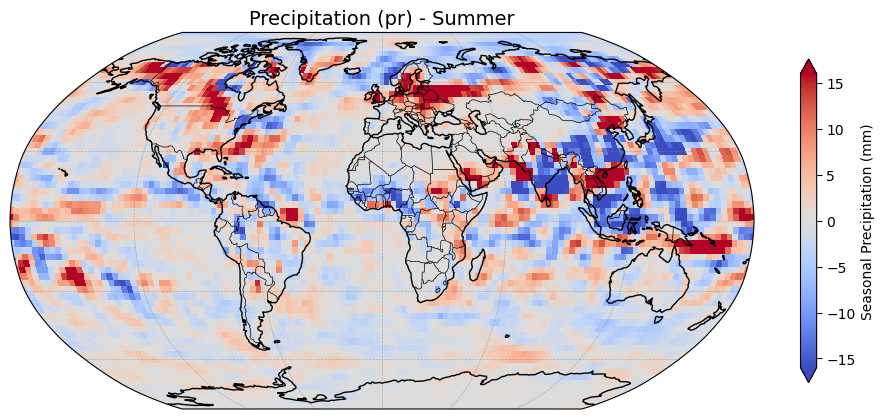

In [12]:
# select dataset
#ds = refs[0]
ds = diff

# select variable
ta = ds["pr"]
ta = ta * 1000 * 3600 * 24 * 91.25

# select first timestep if present
if "time" in ta.dims:
    ta = ta.isel(time=2)

# select first vertical level if present
for lev in ["plev", "lev", "level"]:
    if lev in ta.dims:
        ta = ta.isel({lev: 0})

# create figure with Robinson projection
fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=ccrs.Robinson())

# plot data
p = ta.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    robust=True,                 # avoids outlier color stretching
    cbar_kwargs={
        "label": "Seasonal Precipitation (mm)",
        "shrink": 0.7
    }
)

# add map features
ax.coastlines(linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# gridlines
gl = ax.gridlines(
    draw_labels=False,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

ax.set_title("Precipitation (pr) - Summer", fontsize=14)


plt.savefig("pr_anomaly_season3.png", dpi=300, bbox_inches="tight")
#plt.savefig("ta_scn1_avg_season4.png", dpi=300, bbox_inches="tight")
plt.show()